# <center>Laboratorium 11<br>Metody Numeryczne</center>

In [4]:
import numpy as np
import scipy as sp
from scipy import optimize
from scipy import integrate
import matplotlib
import matplotlib.pyplot as plt
import math


Instrukcja:  
Na zajęciach należy wykonać poniższe zadania, a następnie sporządzić sprawozdanie zawierające odpowiedzi z komentarzami.

**Cel zajęć:**  
Celem zajęć jest zapoznanie się z metodami całkowania numerycznego funkcji:  
$$
\int\limits_{a}^{b}f(x)dx 
$$  

Dana jest funkcja $f(x)$, należy wyznaczyć wartość całki tej funkcji na przedziale $a$,$b$.


***Zadanie 1.***    
Wyznacz numerycznie wartość całki:   
$$
\int\limits_{a}^{b}\log(1+\tan(x))dx 
$$

Wykonaj następujące czynności:

1. Czy możliwe jest całkowanie podanej funkcji na dowolnym przedziale? Swoją odpowiedź uzasadnij.
2. Oblicz całkę numerycznie na przedziale $a =0$, $b=\cfrac{\pi}{4}$ przy pomocy następujących metod:  
    1. Metoda Trapezów - [trapz](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.trapz.html#scipy.integrate.trapz)
    2. Metoda Simpsona - [simps](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.simps.html#scipy.integrate.simps) 
    3. Metoda Romberga - [romb](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.romb.html#scipy.integrate.romb)  
  
Sprawdź jak wyniki róźnią się od siebie, czy ma na nie wpływ długość wektora $\mathbf{y}$ oraz wartość parametru $dx$

3. Porównaj wyniki i czas obliczeń z punktu 1 z funkcjami:
    1. [quad](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html#scipy-integrate-quad)
    2. [romberg](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.romberg.html#scipy.integrate.romberg)
    3. [quadrature](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quadrature.html#scipy.integrate.quadrature)

1)Nie, ponieważ funkcja może zacząć dążyć do nieskończności lub wejść w nieskończone oscylacje na skończonym przedziale


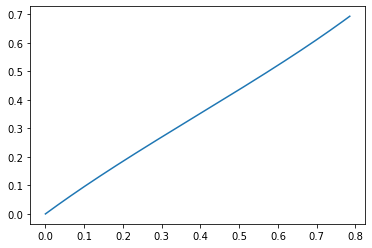

In [5]:
x=np.linspace(0,np.pi/4,1000)
f=lambda x: np.log(1+np.tan(x))
plt.plot(x,f(x))

Text(0.5, 1.0, 'wynik od długości y')

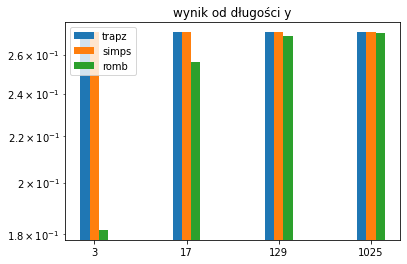

In [6]:
f=lambda x: np.log(1+np.tan(x))
xl=[np.linspace(0,np.pi/4,2**1+1),np.linspace(0,np.pi/4,2**4+1),np.linspace(0,np.pi/4,2**7+1),np.linspace(0,np.pi/4,2**10+1)]
t=[]
s=[]
r=[]
dt=[]
ds=[]
dr=[]

for x in xl:
  t.append(sp.integrate.trapz(f(x),x))
  s.append(sp.integrate.simps(f(x),x))
  r.append(sp.integrate.romb(f(x),np.pi/4/len(x)))
  dt.append(sp.integrate.trapz(f(xl[3]),dx=x[1]))
  ds.append(sp.integrate.simps(f(xl[3]),dx=x[1]))
  dr.append(sp.integrate.romb(f(xl[3]),dx=x[1]))
l=np.arange(4)
w=0.4
plt.bar(l - w/4, t, w/4, label='trapz')
plt.bar(l , s, w/4, label='simps')
plt.bar(l + w/4, r, w/4, label='romb')
labels = ['3', '17', '129','1025']
plt.xticks(l,labels)
plt.legend()
plt.semilogy()
plt.title('wynik od długości y')



Text(0.5, 1.0, 'wynik od dx')

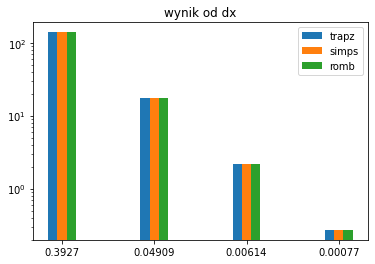

In [7]:
l=np.arange(4)
w=0.4
plt.bar(l - w/4, dt, w/4, label='trapz')
plt.bar(l , ds, w/4, label='simps')
plt.bar(l + w/4, dr, w/4, label='romb')
labels = (np.around(xl[0][1],5), np.around(xl[1][1],5), np.around(xl[2][1],5),np.around(xl[3][1],5))
plt.xticks(l,labels)
plt.legend()
plt.semilogy()
plt.title('wynik od dx')

([<matplotlib.axis.XTick at 0x13621c27460>,
 [Text(1, 0, 'trapz'),
  Text(2, 0, 'simps'),
  Text(3, 0, 'romb'),
  Text(4, 0, 'quad'),
  Text(5, 0, 'quadrature'),
  Text(6, 0, 'romberg')])

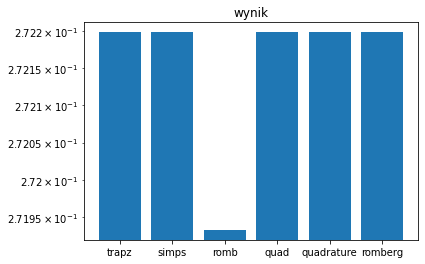

In [8]:
q,qer=sp.integrate.quad(f,0,np.pi/4)
qt,qter=sp.integrate.quadrature(f,0,np.pi/4)
rom=sp.integrate.romberg(f,0,np.pi/4)
x=np.linspace(0,np.pi/4,2**10+1)
t=sp.integrate.trapz(f(x),x)
s=sp.integrate.simps(f(x),x)
r=sp.integrate.romb(f(x),dx=np.pi/4/(2**10 + 1))

v=[t,s,r,q,qt,rom]
l=[1,2,3,4,5,6]
plt.bar(l,v)
plt.semilogy()
plt.title('wynik')
lab=['trapz','simps','romb','quad','quadrature','romberg']
plt.xticks(l,lab)


([<matplotlib.axis.XTick at 0x13621d29340>,
 [Text(1, 0, 'trapz'),
  Text(2, 0, 'simps'),
  Text(3, 0, 'quad'),
  Text(4, 0, 'quadrature'),
  Text(5, 0, 'romberg')])

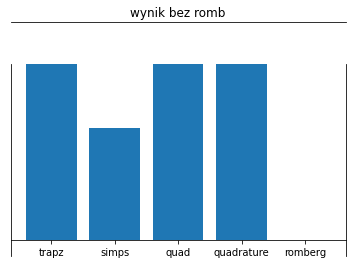

In [9]:
q,qer=sp.integrate.quad(f,0,np.pi/4)
qt,qter=sp.integrate.quadrature(f,0,np.pi/4)
rom=sp.integrate.romberg(f,0,np.pi/4)
x=np.linspace(0,np.pi/4,2**10+1)
t=sp.integrate.trapz(f(x),x)
s=sp.integrate.simps(f(x),x)
r=sp.integrate.romb(f(x),dx=np.pi/4/(2**10 + 1))

v=[t,s,q,qt,rom]
l=[1,2,3,4,5]
plt.bar(l,v)
plt.semilogy()
plt.title('wynik bez romb')
lab=['trapz','simps','quad','quadrature','romberg']
plt.xticks(l,lab)

21.9 µs ± 3.9 µs per loop (mean ± std. dev. of 100 runs, 100 loops each)
39.1 µs ± 3.08 µs per loop (mean ± std. dev. of 100 runs, 100 loops each)
23.7 µs ± 833 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
24.7 µs ± 559 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
39.8 µs ± 1.47 µs per loop (mean ± std. dev. of 100 runs, 100 loops each)
306 µs ± 9.07 µs per loop (mean ± std. dev. of 100 runs, 100 loops each)


([<matplotlib.axis.XTick at 0x13621d78a90>,
 [Text(1, 0, 'romberg'),
  Text(2, 0, 'quad'),
  Text(3, 0, 'quadrature'),
  Text(4, 0, 'trapz'),
  Text(5, 0, 'simps'),
  Text(6, 0, 'romb')])

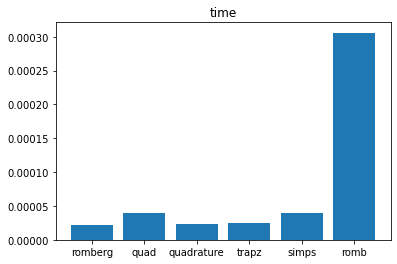

In [10]:
t=[]
tp=%timeit -r 100 -n 100 -o sp.integrate.romberg(f,0,np.pi/4)
t.append(tp.average)
tp=%timeit -r 100 -n 100 -o sp.integrate.quad(f,0,np.pi/4)
t.append(tp.average)
tp=%timeit -r 100 -n 100 -o sp.integrate.quadrature(f,0,np.pi/4)
t.append(tp.average)

x=np.linspace(0,np.pi/4,2**10+1)
tp=%timeit -r 100 -n 100 -o sp.integrate.trapz(f(x),x)
t.append(tp.average)
tp=%timeit -r 100 -n 100 -o sp.integrate.simps(f(x),x)
t.append(tp.average)
tp=%timeit -r 100 -n 100 -o sp.integrate.romb(f(x),x)
t.append(tp.average)

l=[1,2,3,4,5,6]
plt.bar(l,t)
plt.title('time')
lab=['romberg','quad','quadrature','trapz','simps','romb']
plt.xticks(l,lab)

***Zadanie 2.***  
Dla funkcji 

$$f(x) = e^{x^2}$$

wyznacz numerycznie wartośc całki na przedziale $a = 0$, $b=1$  w  taki sam sposób jak w zadaniu 1.

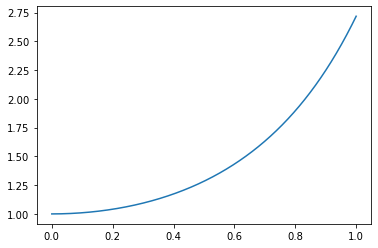

In [11]:
x=np.linspace(0,1,1000)
f=lambda x:np.exp(x**2)
plt.plot(x,f(x))

Text(0.5, 1.0, 'wynik od długości y')

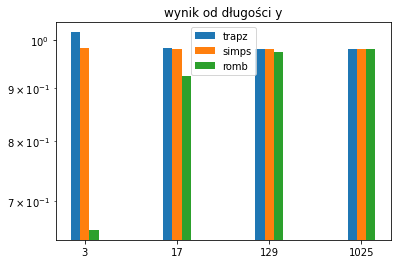

In [12]:

xl=[np.linspace(0,np.pi/4,2**1+1),np.linspace(0,np.pi/4,2**4+1),np.linspace(0,np.pi/4,2**7+1),np.linspace(0,np.pi/4,2**10+1)]
t=[]
s=[]
r=[]
dt=[]
ds=[]
dr=[]

for x in xl:
  t.append(sp.integrate.trapz(f(x),x))
  s.append(sp.integrate.simps(f(x),x))
  r.append(sp.integrate.romb(f(x),np.pi/4/len(x)))
  dt.append(sp.integrate.trapz(f(xl[3]),dx=x[1]))
  ds.append(sp.integrate.simps(f(xl[3]),dx=x[1]))
  dr.append(sp.integrate.romb(f(xl[3]),dx=x[1]))
l=np.arange(4)
w=0.4
plt.bar(l - w/4, t, w/4, label='trapz')
plt.bar(l , s, w/4, label='simps')
plt.bar(l + w/4, r, w/4, label='romb')
labels = ['3', '17', '129','1025']
plt.xticks(l,labels)
plt.legend()
plt.semilogy()
plt.title('wynik od długości y')

Text(0.5, 1.0, 'wynik od dx')

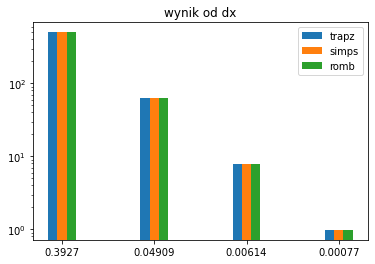

In [13]:
l=np.arange(4)
w=0.4
plt.bar(l - w/4, dt, w/4, label='trapz')
plt.bar(l , ds, w/4, label='simps')
plt.bar(l + w/4, dr, w/4, label='romb')
labels = (np.around(xl[0][1],5), np.around(xl[1][1],5), np.around(xl[2][1],5),np.around(xl[3][1],5))
plt.xticks(l,labels)
plt.legend()
plt.semilogy()
plt.title('wynik od dx')

([<matplotlib.axis.XTick at 0x13621b400a0>,
 [Text(1, 0, 'trapz'),
  Text(2, 0, 'simps'),
  Text(3, 0, 'romb'),
  Text(4, 0, 'quad'),
  Text(5, 0, 'quadrature'),
  Text(6, 0, 'romberg')])

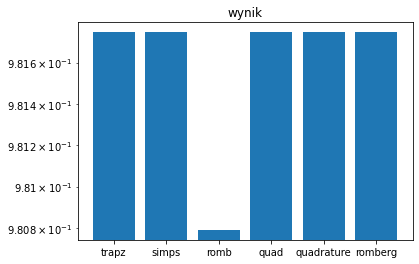

In [14]:
q,qer=sp.integrate.quad(f,0,np.pi/4)
qt,qter=sp.integrate.quadrature(f,0,np.pi/4)
rom=sp.integrate.romberg(f,0,np.pi/4)
x=np.linspace(0,np.pi/4,2**10+1)
t=sp.integrate.trapz(f(x),x)
s=sp.integrate.simps(f(x),x)
r=sp.integrate.romb(f(x),dx=np.pi/4/(2**10 + 1))

v=[t,s,r,q,qt,rom]
l=[1,2,3,4,5,6]
plt.bar(l,v)
plt.semilogy()
plt.title('wynik')
lab=['trapz','simps','romb','quad','quadrature','romberg']
plt.xticks(l,lab)

([<matplotlib.axis.XTick at 0x13623014a60>,
 [Text(1, 0, 'trapz'),
  Text(2, 0, 'simps'),
  Text(3, 0, 'quad'),
  Text(4, 0, 'quadrature'),
  Text(5, 0, 'romberg')])

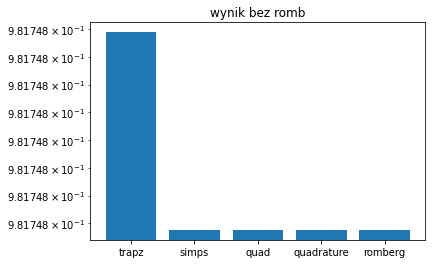

In [15]:
q,qer=sp.integrate.quad(f,0,np.pi/4)
qt,qter=sp.integrate.quadrature(f,0,np.pi/4)
rom=sp.integrate.romberg(f,0,np.pi/4)
x=np.linspace(0,np.pi/4,2**10+1)
t=sp.integrate.trapz(f(x),x)
s=sp.integrate.simps(f(x),x)
r=sp.integrate.romb(f(x),dx=np.pi/4/(2**10 + 1))

v=[t,s,q,qt,rom]
l=[1,2,3,4,5]
plt.bar(l,v)
plt.semilogy()
plt.title('wynik bez romb')
lab=['trapz','simps','quad','quadrature','romberg']
plt.xticks(l,lab)

120 µs ± 5.84 µs per loop (mean ± std. dev. of 100 runs, 100 loops each)
17.4 µs ± 987 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
66 µs ± 3.54 µs per loop (mean ± std. dev. of 100 runs, 100 loops each)
19.5 µs ± 1.49 µs per loop (mean ± std. dev. of 100 runs, 100 loops each)
36.9 µs ± 2.19 µs per loop (mean ± std. dev. of 100 runs, 100 loops each)
301 µs ± 11.3 µs per loop (mean ± std. dev. of 100 runs, 100 loops each)


([<matplotlib.axis.XTick at 0x13623089e80>,
 [Text(1, 0, 'romberg'),
  Text(2, 0, 'quad'),
  Text(3, 0, 'quadrature'),
  Text(4, 0, 'trapz'),
  Text(5, 0, 'simps'),
  Text(6, 0, 'romb')])

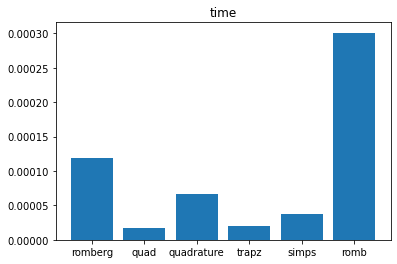

In [16]:
t=[]
tp=%timeit -r 100 -n 100 -o sp.integrate.romberg(f,0,np.pi/4)
t.append(tp.average)
tp=%timeit -r 100 -n 100 -o sp.integrate.quad(f,0,np.pi/4)
t.append(tp.average)
tp=%timeit -r 100 -n 100 -o sp.integrate.quadrature(f,0,np.pi/4)
t.append(tp.average)

x=np.linspace(0,np.pi/4,2**10+1)
tp=%timeit -r 100 -n 100 -o sp.integrate.trapz(f(x),x)
t.append(tp.average)
tp=%timeit -r 100 -n 100 -o sp.integrate.simps(f(x),x)
t.append(tp.average)
tp=%timeit -r 100 -n 100 -o sp.integrate.romb(f(x),x)
t.append(tp.average)

l=[1,2,3,4,5,6]
plt.bar(l,t)
plt.title('time')
lab=['romberg','quad','quadrature','trapz','simps','romb']
plt.xticks(l,lab)

Text(0.5, 1.0, 'charakterystyka statyczna układu czujnik + tor z modulacją amplitudową')

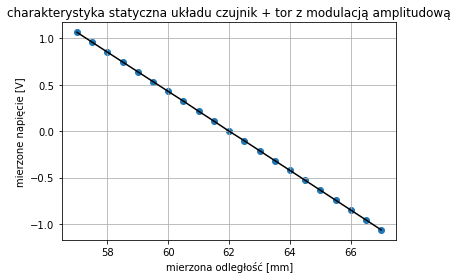

In [61]:
l1=np.linspace(57,67,21)
y1=[1.067, 0.96, 0.853, 0.747, 0.641, 0.535, 0.429, 0.324, 0.215, 0.109, 0 ,-0.103, -0.21, -0.317, -0.423, -0.53, -0.637, -0.744, -0.851, -0.958, -1.065]
plt.scatter(l1,y1)
plt.plot(l1,y1,'k')
plt.xlabel('mierzona odległość [mm]')
plt.ylabel('mierzone napięcie [V]')
plt.grid()
plt.title('charakterystyka statyczna układu czujnik + tor z modulacją amplitudową')

Text(0.5, 1.0, 'charakterystyka statyczna czujnika LVDT')

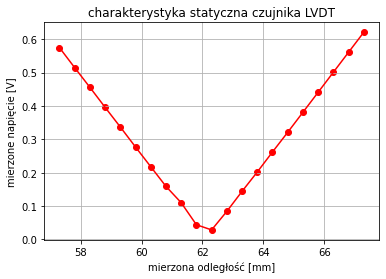

In [56]:
l2=np.linspace(57.3,67.3,21)
y2=[0.575, 0.515, 0.456, 0.396, 0.337, 0.277, 0.218, 0.159, 0.11, 0.044, 0.0284, 0.084, 0.144, 0.202, 0.262, 0.321, 0.381, 0.441, 0.501, 0.561, 0.621]
y3=[-0.575, -0.515, -0.456, -0.396, -0.337, -0.277, -0.218, -0.159, -0.11, -0.044, 0.0284, 0.084, 0.144, 0.202, 0.262, 0.321, 0.381, 0.441, 0.501, 0.561, 0.621]
plt.scatter(l2,y2,c='r')
plt.plot(l2,y2,'r')
plt.xlabel('mierzona odległość [mm]')
plt.ylabel('mierzone napięcie [V]')
plt.grid()
plt.title('charakterystyka statyczna czujnika LVDT')


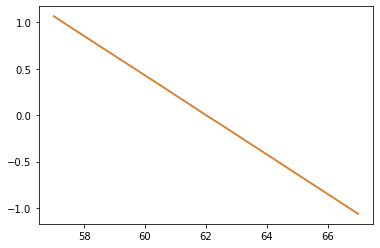

In [62]:
plt.plot(l1,y1)
mean_x = np.mean(l1)
mean_y = np.mean(y1)
 
# Total number of values
n = len(l1)
 
# Using the formula to calculate m and c
numer = 0
denom = 0
for i in range(n):
 numer += (l1[i] - mean_x) * (y1[i] - mean_y)
 denom += (l1[i] - mean_x) ** 2
m = numer / denom
c = mean_y - (m * mean_x)
regy=l1*m+c
plt.plot(l1,regy)

0.0011141297726660038


Text(0.5, 1.0, 'charakterystyka bezwzględnego błędu nieliniowości w funkcji przesunięcia x')

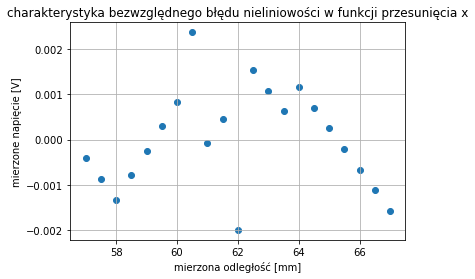

In [63]:
r_bez=y1-regy
plt.scatter(l1,r_bez)
print(max(abs(r_bez))/(max(y1)-min(y1)))
plt.xlabel('mierzona odległość [mm]')
plt.ylabel('mierzone napięcie [V]')
plt.grid()
plt.title('charakterystyka bezwzględnego błędu nieliniowości w funkcji przesunięcia x')